# **MODELO DE DEEP ENSEMBLE LEARNING PARA PREVENCIÓN DE ENFERMEDADES Y PLAGAS EN LA VID A PARTIR DE DATOS TABULARES**

Modelo para clasificar y detectar con anticipación la presencia de patologías y plagas en cultivos de vid utilizando un modelo de **Deep Ensemble Learning**. El sistema emplea redes LSTM, CNN-1D y BiGRU para analizar secuencias temporales de sensores meteorológicos, de suelo y térmicos.

### **DICCIONARIO DE TRATAMIENTOS**

Basándonos en el documento:

**Espadas, A. L. (2008). Plagas y enfermedades de la vid en la Región de Murcia. Murcia, Consejería de Agricultura y Agua Servicio de Sanidad Vegetal.**

Disponemos de los tratamientos apropiados para cada una de estas plagas/enfermedades. Acompañaremos con esta información a las predicciones.

In [43]:
BASE_CONOCIMIENTO_TRATAMIENTOS = {
    "HEALTHY": {
        "Diagnóstico": "Planta sana. No se detectan patrones de estrés biológico.",
        "Recomendación": "Mantener monitorización habitual. No requiere intervención."
    },
    "LOBESIA": {
        "Químico": "Impregnar bien racimos. Bacillus thuringiensis (inicio eclosión), clorpirifos, fenoxicarb, flufenoxuron, metoxifenocide, tebufenocide.",
        "Biológico": "Crysopa carnea, Dybrachys spp., Coccinélidos (poca trascendencia en campaña). Mejor acción parasitaria en invierno sobre crisálidas.",
        "Biotecnológico": "Confusión sexual (Isonet L / Quant Lb) a 500/350 difusores/ha. Alternativa: Puffers (4-8 aerosoles/ha) sincronizados con vuelo.",
        "Cultural": "Poda en verde para ventilar racimos y exponerlos a insecticidas."
    },
    "EMPOASCA": {
        "Químico": "Tratar focos de larvas/ninfas. Acrinatrin (uva de mesa), clorpirifos, flufenoxuron, imidacloprid.",
        "Biológico": "Anagrus atomus (baja eficiencia en vid).",
        "Biotecnológico": "Placas amarillas engomadas en perímetros e interior de parcela.",
        "Cultural": "Eliminar malas hierbas en invierno (hospedantes). Controlar el vigor para evitar brotación excesivamente tierna."
    },
    "ALTICA": {
        "Químico": "Generalmente controlado por tratamientos para Lobesia. Específicos: Lambda cihalotrin y clorpirifos.",
        "Biológico": "Depredador Zicrona coerulea (chinche azul) y polífagos.",
        "Biotecnológico": "No establecido.",
        "Cultural": "Refugios trampa al final del verano (sacos/paja en el tronco) para capturar y destruir adultos invernantes. Mantener terreno limpio."
    },
    "RED_MITE": {
        "Químico": "Mojar brotes/madera en invierno. En otoño, mojar haz de las hojas. Aceite mineral (ovicida), acrinatrin, dicofol, fenbutestan, piridaben.",
        "Biológico": "Fitoséidos espontáneos (ej. Phytoseiulus persimilis) si no se usan químicos agresivos.",
        "Biotecnológico": "No establecido.",
        "Cultural": "Eliminar puestas de invierno mediante poda. Controlar vigor. Evitar frutales aislados cercanos a la parcela."
    },
    "ERINOSIS": {
        "Químico": "Raramente necesario. Azufre (mismo que Oidio) suele bastar. Dicofol en casos severos de raza de yemas (estados fenológicos C/D y G/H).",
        "Biológico": "Fitoséidos depredadores (Typhlodromus pyri, T. phialatus).",
        "Biotecnológico": "No establecido.",
        "Cultural": "Quemar restos de poda infectados. No usar yemas de plantas enfermas para reproducción."
    },
    "ESCA": {
        "Químico": "Solo preventivo post-poda en heridas (cubiet, quinosol, tebuconazol+resinas). Inútil si la planta ya está contaminada.",
        "Biológico": "No establecido.",
        "Biotecnológico": "No establecido.",
        "Cultural": "Poda hasta madera sana y aplicar mastic. Podar cepas enfermas al final. Desinfectar herramientas. Marcar cepas en vegetativo. Técnica de abrir la cruz con cuña (aerobiosis)."
    },
    "OIDIO": {
        "Químico": "Mojar adecuadamente racimos. Poda/deshojado previo. Azufre y fungicidas antioídio específicos.",
        "Biológico": "No establecido.",
        "Biotecnológico": "No establecido.",
        "Cultural": "Deshojado basal del sarmiento (2-3 hojas). Eliminar brotes secundarios sin fruto. Control del vigor vegetativo excesivo."
    },
    "MILDIU": {
        "Químico": "Hasta tamaño guisante: Sistémicos/penetrantes. Desde envero: De contacto. Preventivo al inicio de floración.",
        "Biológico": "No establecido.",
        "Biotecnológico": "No establecido.",
        "Cultural": "Buena aireación (deshojados y podas en verde). Controlar microclima en plantaciones bajo plástico."
    },
    "BOTRYTIS": {
        "Químico": "Preventivos fijos o Método 15-15 (humedad/temp). Boscalida, ciprodinil, fenhexamida, fludioxonil, pirimetanil.",
        "Biológico": "No establecido.",
        "Biotecnológico": "No establecido.",
        "Cultural": "Deshojado manual/mecánico de racimos. Control estricto de polilla/oídio (puertas de entrada). Evitar exceso de nitrógeno."
    },
    "BLACK_ROT": {
        "Químico": "Preventivo desde brotación a tamaño guisante. Alternar contacto (Mancozeb, folpet) con sistémicos (Miclobutanil, triazoles).",
        "Biológico": "No establecido.",
        "Biotecnológico": "Sistemas IoT / Modelos predictivos de humedad foliar (Spotts).",
        "Cultural": "Eliminación obligatoria y quema de 'momias' (uvas secas del año anterior). Deshojado/espergurado para aireación."
    }
}

### **LIBRERÍAS**

In [44]:
import os
import tensorflow as tf

# Vinculamos la ruta de las librerías matemáticas de sistema
os.environ['LD_LIBRARY_PATH'] = '/usr/local/cuda-12.3/lib64:' + os.environ.get('LD_LIBRARY_PATH', '')

print(f"TensorFlow versión: {tf.__version__}")
print(f"GPU disponible: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow versión: 2.21.0
GPU disponible: False


In [45]:
# ==============================================================================
# 0. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN INICIAL
# ==============================================================================

# --- Manipulación de Datos y Visualización ---
import pandas as pd                 # Para el manejo de datos tabulares, DataFrames y análisis exploratorio.
import numpy as np                  # Operaciones matriciales, vectores y arrays multidimensionales de alta eficiencia.
import matplotlib.pyplot as plt     # Gráficos simples.
import seaborn as sns               # Gráficos estadísticos complejos.

# --- Utilidades del Sistema y Flujo de Memoria ---
import os                           # Interacción con el SO y variables de entorno del equipo.
import joblib                       # Guardar (dump) objetos/preprocesadores grandes de Scikit-Learn.
import time                         # Evaluar latencias y cronometrar los scripts.
from tqdm import tqdm               # Barra de progreso durante iteraciones largas.
import gc                           # Garbage Collector: Borrado de la RAM 
import random                       # Aleatoriedad
from itertools import cycle         # Iterar infinitamente de un bloque circular de objetos y listas.
from pathlib import Path            # Mapear rutas del disco al SO.
import pickle                       # Estandarización Python pura 

# --- Deep Learning: TensorFlow y Keras ---
import tensorflow as tf     # Backend completo de IA para operaciones tensoriales.
from tensorflow.keras.models import Model, load_model   # API Computacional Funcional de Keras y Cargar Modelo.
from tensorflow.keras.optimizers import Adam            # Optimizador para ajustar la pérdida con gradiente estocástico.
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint    # Métodos de vigilancia para parar de aprender si el loss del Valid se estanca.
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization               # Arquitectura para conectividad completa (Dense) y regularizadores del sobreajuste (Dropout/BatchNorm).
from tensorflow.keras.layers import LSTM, GRU, Bidirectional                                # Redes recurrentes: para el entendimiento temporal clásico e incubativo (memoria).
from tensorflow.keras.layers import Conv1D, GlobalAveragePooling1D, MaxPooling1D            # Redes convolucionales: capaces de detectar rápidamente caídas/subidas y picos de alerta sin basarse en contexto lejano.

# --- Machine Learning Numérico y Métricas Clásicas (Scikit-Learn) ---
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler    # Escalado físico y codificador binario para preparar features.
from sklearn.model_selection import train_test_split    # Realiza "Holdout"; es tu base real de división controlada en capas representativas (estratificadas).
from sklearn.utils import class_weight                  # Computa los desbalances permitiéndote penalizar en coste a la red por fallar las muestras extrañas.
from sklearn.preprocessing import label_binarize        # Binarización útil para análisis complejos ROC.
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score # Toolkit de evaluación técnica multiclase (Clasificación).
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score   # Toolkit para evaluación de regresión (El 'Grade de infeción' analóguco calculado).

# --- Configuración Global ---
pd.set_option('display.max_columns', None)  # Muestra todas las columnas de df
np.random.seed(42)                          # Replicabilidad

### **CONFIGURACIÓN DE RUTAS E HIPERPARÁMETROS**

In [46]:
# RUTAS DE LOS DATOS EN CRUDO:
INPUT_DIR = Path("../../data/processed/")
NOMBRE_INPUT = "data_vin_processed.parquet"

# RUTAS DE GUARDADO DE ARTEFACTOS
RUTA_MODELS_DIR = Path("../../models/artifacts/")
RUTA_MODELS_DIR.mkdir(parents=True, exist_ok=True)

NOMBRE_SCALER = "scaler.pkl"
NOMBRE_LABEL_ENCODER = "label_encoder.pkl"

NOMBRE_MODELO_LSTM = "M1_LSTM.keras"
NOMBRE_MODELO_CNN = "M2_CNN.keras"
NOMBRE_MODELO_BI_GRU = "M3_BiGRU.keras"

# RUTAS DE LA SALIDA DEL MODELO:
OUTPUT_DIR = Path("../../data/predictions/")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
NOMBRE_PREDICT_CSV = "inferencia_vid.csv"

# CONFIGURACIONES DEL MODELO:
DIAS_CONTEXTO = 7   # Días de contexto
WINDOW_SIZE = DIAS_CONTEXTO * 24    # Horas de contexto
BATCH_SIZE = 512   # Memoria
EPOCHS = 50         # Epocas de entrenamiento
EARLY_STOPPING = 2  # Patience

### **CARGA DE DATOS**

In [47]:
ruta_raw = INPUT_DIR / NOMBRE_INPUT
df = pd.read_parquet(ruta_raw)
pd.set_option('display.max_columns', None)
display(df.head())

,CO2_ppm,Clase_Entrenamiento,Etiqueta_Clase,Fecha,Grado_Infeccion,Hum_Rel_Pct,Hum_Suelo_Pct,ID_Serie,Lluvia_mm,Parcela_ID,Temp_Amb_C,VOC_ppb,Viento_kmh,pH_Suelo,Hora,Hora_Sin,Hora_Cos,GDD_Acumulado,Horas_Humedad_Foliar
0,398.813232,HEALTHY,LOBESIA,2023-04-19 18:00:00,0.005047,21.0,28.960115,0,0.0,ribera_del_duero,23.299999,61.444447,8.0,6.904538,18,-1.000000,-1.836970e-16,5.883334,0.0
1,397.811279,HEALTHY,LOBESIA,2023-04-19 19:00:00,0.005047,20.0,28.955692,0,0.0,ribera_del_duero,23.000000,74.952682,6.9,6.912406,19,-0.965926,2.588190e-01,5.883334,0.0
2,439.846436,HEALTHY,LOBESIA,2023-04-19 20:00:00,0.005047,34.0,28.953594,0,0.0,ribera_del_duero,21.200001,83.156921,4.3,6.904041,20,-0.866025,5.000000e-01,5.883334,0.0
3,426.677887,HEALTHY,LOBESIA,2023-04-19 21:00:00,0.005047,31.0,28.953119,0,0.0,ribera_del_duero,17.700001,53.178280,7.8,6.925395,21,-0.707107,7.071068e-01,5.883334,0.0
4,423.542206,HEALTHY,LOBESIA,2023-04-19 22:00:00,0.005047,33.0,28.953119,0,0.0,ribera_del_duero,16.100000,62.143723,8.3,6.900627,22,-0.500000,8.660254e-01,5.883334,0.0


### **PREPROCESAMIENTO (PIPELINE DE ETL)**

In [48]:
# ==============================================================================
# 1. ASEGURAR FORMATO
# ==============================================================================
# Orden alfabético
df = df.reindex(sorted(df.columns), axis=1)
    
# Asegurar tipos string para evitar errores en el modelo:
cols_str = ['Etiqueta_Clase', 'Clase_Entrenamiento']
for col in cols_str:
    if col in df.columns:
        df[col] = df[col].astype(str)

# ==============================================================================
# 2. CODIFICACIÓN DE TARGETS
# ==============================================================================
le = LabelEncoder()
# TARGET: El estado real en ese instante temporal
df['Etiqueta_Num'] = le.fit_transform(df['Clase_Entrenamiento']) 
print(f"✅ Clases codificadas: {dict(zip(le.classes_, range(len(le.classes_))))}")

# ==============================================================================
# 3. SELECCIÓN DE VARIABLES
# ==============================================================================
# Quitamos Fecha (ya no sirve a la red), ID_Serie (no es predictiva) y Etiquetas crudas
cols_features = [
    'Temp_Amb_C', 
    'Hum_Rel_Pct', 'Lluvia_mm', 'Viento_kmh', 
    'Horas_Humedad_Foliar', 'GDD_Acumulado', 
    'Hum_Suelo_Pct', 'pH_Suelo',
    'CO2_ppm', 'VOC_ppb',
    'Hora_Sin', 'Hora_Cos'
]

target_class = 'Etiqueta_Num'
target_reg = 'Grado_Infeccion'

# ==============================================================================
# 4. SPLIT ESTRATÉGICO ESTRATIFICADO (POR ID_SERIE, NUNCA ALEATORIO POR FILA)
# ==============================================================================
# 1. Obtenemos un diccionario 1 a 1 de cada ID_Serie con su patología general
df_unicos = df.drop_duplicates(subset=['ID_Serie'])[['ID_Serie', 'Etiqueta_Clase']]

ids = df_unicos['ID_Serie']
etiquetas = df_unicos['Etiqueta_Clase']

# 2. Primer Split: 70% Train, 30% Temp (Estratificado por la etiqueta)
train_ids, temp_ids, _, temp_etiquetas = train_test_split(
    ids, etiquetas, 
    test_size=0.30, 
    random_state=42, 
    stratify=etiquetas
)

# 3. Segundo Split: Dividimos el 30% restante en 15% Val y 15% Test
val_ids, test_ids = train_test_split(
    temp_ids, 
    test_size=0.50, 
    random_state=42, 
    stratify=temp_etiquetas
)

# 4. Reconstruimos los DataFrames completos usando los IDs seleccionados
train_df = df[df['ID_Serie'].isin(train_ids)].copy()
val_df = df[df['ID_Serie'].isin(val_ids)].copy()
test_df = df[df['ID_Serie'].isin(test_ids)].copy()

print(f"📊 Series separadas -> Train: {len(train_ids)} | Val: {len(val_ids)} | Test: {len(test_ids)}")

# ==============================================================================
# 5. ESCALADO (SOLO FIT EN TRAIN)
# ==============================================================================
scaler = StandardScaler()
# Ajustamos solo en train para evitar fuga de datos
scaler.fit(train_df[cols_features])

# Transformamos todos
train_df[cols_features] = scaler.transform(train_df[cols_features])
val_df[cols_features] = scaler.transform(val_df[cols_features])
test_df[cols_features] = scaler.transform(test_df[cols_features])
print("✅ Datos escalados correctamente.")

# ==============================================================================
# 6. GENERACIÓN DE VENTANAS TEMPORALES (MEMORIA OPTIMIZADA)
# ==============================================================================
def crear_secuencias(df_part, window_size, features, t_class, t_reg):
    X, y_c, y_r = [], [], []
    grupos = df_part.groupby('ID_Serie')
    
    for _, grupo in tqdm(grupos, desc="Generando tensores", leave=False):
        data_features = grupo[features].values
        data_class = grupo[t_class].values
        data_reg = grupo[t_reg].values
        
        # Deslizamiento de ventana
        for i in range(len(data_features) - window_size):
            X.append(data_features[i : i + window_size])
            # El target es el estado al FINAL de la ventana
            y_c.append(data_class[i + window_size])
            y_r.append(data_reg[i + window_size])
            
    return np.array(X, dtype=np.float32), np.array(y_c, dtype=np.int8), np.array(y_r, dtype=np.float32)

print("\n🚀 Empaquetando tensores 3D (Esto tomará un minuto)...")
X_train, y_train_class, y_train_reg = crear_secuencias(train_df, WINDOW_SIZE, cols_features, target_class, target_reg)
X_val, y_val_class, y_val_reg = crear_secuencias(val_df, WINDOW_SIZE, cols_features, target_class, target_reg)
X_test, y_test_class, y_test_reg = crear_secuencias(test_df, WINDOW_SIZE, cols_features, target_class, target_reg)

# Limpiar RAM
del train_df, val_df, test_df
gc.collect()

✅ Clases codificadas: {'ALTICA': 0, 'BLACK_ROT': 1, 'BOTRYTIS': 2, 'EMPOASCA': 3, 'ERINOSIS': 4, 'ESCA': 5, 'HEALTHY': 6, 'LOBESIA': 7, 'MILDIU': 8, 'OIDIO': 9, 'RED_MITE': 10}
📊 Series separadas -> Train: 692 | Val: 148 | Test: 149
✅ Datos escalados correctamente.

🚀 Empaquetando tensores 3D (Esto tomará un minuto)...


93735

### **CREACIÓN DE LAS REDES: Deep Ensemble Learning (DEL)**

Las tres redes neuronales que planteamos serán:
* **Red 1 (LSTM)**: Experta en memoria a largo plazo (acumulación térmica, incubación).
* **Red 2 (CNN-1D)**: Experta en detectar picos o caídas bruscas locales (gatillos de infección).
* **Red 3 (GRU Bidireccional)**: LSTM optimizada que lee la secuencia temporal en ambas direcciones para encontrar relaciones de contexto complejas.

---

Mejores hiperparámetros de cada modelo encontrados por `Optimizacion_DEL_CrossValidation.ipynb`:
* **LSTM:** {'lstm_1': 8, 'dropout': 0.2, 'lstm_2': 32, 'learning_rate': 0.001, 'batch_size': 512}
* **CNN:** {'filters_1': 16, 'kernel_1': 3, 'filters_2': 32, 'kernel_2': 3, 'dropout': 0.2, 'learning_rate': 0.001, 'batch_size': 512}
* **BiGRU:** {'gru_units': 16, 'dropout': 0.2, 'dense_units': 8, 'learning_rate': 0.001, 'batch_size': 512}

**NOTA IMPORTANTE:** Debido a las pocas trials y épocas (`N_TRIALS = 10` y `EPOCHS = 10`) que se realizaron a la hora de ejecutar el random search por cuestiones de tiempo y plazos de entrega, lo aconsejable para entrenar con los óptimos sería ejecutar el notebook `Optimizacion_DEL_CrossValidation.ipynb` de nuevo con unos `N_TRIALS` y `EPOCHS` mayores.


In [ ]:
# ==============================================================================
# 7. DEEP ENSEMBLE LEARNING: DEFINICIÓN DE LAS 3 REDES
# ==============================================================================
NUM_FEATURES = len(cols_features)  
NUM_CLASSES = len(le.classes_)
tf.keras.utils.set_random_seed(42)

def compilar_modelo(modelo, lr):
    modelo.compile(
        optimizer=Adam(learning_rate=lr),
        loss={"out_class": "sparse_categorical_crossentropy", "out_reg": "mse"},
        loss_weights={"out_class": 1.0, "out_reg": 1.0},
        metrics={"out_class": ["accuracy"], "out_reg": ["mae"]}
    )
    return modelo

# --- MODELO 1: LSTM PURA ---
def build_lstm_model():
    inp = Input(shape=(WINDOW_SIZE, NUM_FEATURES), name="Input_M1")
    x = LSTM(8, return_sequences=True)(inp)  
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)                       
    x = LSTM(32)(x)                           
    x = BatchNormalization()(x)
    
    out_class = Dense(NUM_CLASSES, activation='softmax', name="out_class")(x)
    out_reg = Dense(1, activation='sigmoid', name="out_reg")(x)
    return compilar_modelo(Model(inputs=inp, outputs=[out_class, out_reg], name="M1_LSTM"), lr=0.001) 

# --- MODELO 2: CNN-1D ---
def build_cnn_model():
    inp = Input(shape=(WINDOW_SIZE, NUM_FEATURES), name="Input_M2")
    x = Conv1D(filters=16, kernel_size=3, activation='relu', padding='same')(inp) 
    x = BatchNormalization()(x)
    x = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(x)  
    x = BatchNormalization()(x)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.2)(x)                                                           
    
    out_class = Dense(NUM_CLASSES, activation='softmax', name="out_class")(x)
    out_reg = Dense(1, activation='sigmoid', name="out_reg")(x)
    return compilar_modelo(Model(inputs=inp, outputs=[out_class, out_reg], name="M2_CNN"), lr=0.001)

# --- MODELO 3: GRU BIDIRECCIONAL ---
def build_bigru_model():
    inp = Input(shape=(WINDOW_SIZE, NUM_FEATURES), name="Input_M3")
    x = Bidirectional(GRU(16, return_sequences=False))(inp)   
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)                                       
    x = Dense(8, activation='relu')(x)                       
    
    out_class = Dense(NUM_CLASSES, activation='softmax', name="out_class")(x)
    out_reg = Dense(1, activation='sigmoid', name="out_reg")(x)
    return compilar_modelo(Model(inputs=inp, outputs=[out_class, out_reg], name="M3_BiGRU"), lr=0.001)

# Instanciamos los 3 modelos
m1_lstm = build_lstm_model()
m2_cnn = build_cnn_model()
m3_bigru = build_bigru_model()

### **ENTRENAMIENTO**

Al haber tantos datos, imponemos las siguientes reglas para la celda de entrenamiento:
* Usar EarlyStopping para que corte el entrenamiento si la red ya no mejora.
* Entrenarlas secuencialmente en un bucle y liberar memoria entre cada una.

In [8]:
# ==============================================================================
# 8. ENTRENAMIENTO DEL ENSEMBLE Y GUARDADO DE ARTEFACTOS
# ==============================================================================

# 1. Guardar los preprocesadores inmediatamente de forma segura
joblib.dump(scaler, RUTA_MODELS_DIR / NOMBRE_SCALER)
joblib.dump(le, RUTA_MODELS_DIR / NOMBRE_LABEL_ENCODER)
print("Preprocesadores guardados en: ", RUTA_MODELS_DIR.resolve())

modelos = [m1_lstm, m2_cnn, m3_bigru]
historiales = []

print("\nIniciando entrenamiento secuencial de las redes: ", len(modelos))

start_time_total = time.time()      # INICIO DE CRONÓMETRO TOTAL

for i, modelo in enumerate(modelos):
    print("\n" + "="*50)
    print("Entrenando Modelo: ", modelo.name)
    print("="*50)
    
    start_time_model = time.time()  # INICIO DE CRONÓMETRO MODELO

    # Pre-definimos la ruta donde se guardara ESTE modelo en concreto
    ruta_modelo = RUTA_MODELS_DIR / f"{modelo.name}.keras"
    
    # Instanciamos los Callbacks desde cero para que no crucen historial entre redes
    early_stop_individual = EarlyStopping(
        monitor='val_loss', 
        patience=EARLY_STOPPING, 
        restore_best_weights=True,
        verbose=1
    )
    
    checkpoint_individual = ModelCheckpoint(
        filepath=ruta_modelo,
        monitor='val_loss',        # Vigilamos la perdida de validacion global
        save_best_only=True,       # Solo sobreescribe si la red mejora en esta epoca
        mode='min',                # Queremos minimizar el val_loss
        verbose=1
    )
    
    # Inicia el entrenamiento (Fit)
    hist = modelo.fit(
        X_train, 
        {"out_class": y_train_class, "out_reg": y_train_reg},
        validation_data=(X_val, {"out_class": y_val_class, "out_reg": y_val_reg}),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop_individual, checkpoint_individual],
        verbose=1
    )
    
    # La red (.keras) ya ha sido guardada en su mejor punto por el Checkpoint.
    # Ahora solo necesitamos guardar el historial de la funcion de perdida.
    ruta_historial = RUTA_MODELS_DIR / f"history_{modelo.name}.csv"
    pd.DataFrame(hist.history).to_csv(ruta_historial, index_label='epoch')
        
    historiales.append(hist.history)
    print("Historial guardado en CSV con exito: ", modelo.name)

    end_time_model = time.time()    # FIN DE CRONÓMETRO MODELO
    elapsed_model_mins = (end_time_model - start_time_model) / 60.0
    print(f"⏱️ Tiempo de entrenamiento para {modelo.name}: {elapsed_model_mins:.2f} minutos.")

end_time_total = time.time()        # FIN DE CRONÓMETRO TOTAL
elapsed_total_mins = (end_time_total - start_time_total) / 60.0
print(f"\n⏱️ TIEMPO TOTAL DE ENTRENAMIENTO DEL ENSEMBLE: {elapsed_total_mins:.2f} minutos.")

print("\nENTRENAMIENTO Y EXPORTACION COMPLETADOS. Todos los archivos estan seguros en: ", RUTA_MODELS_DIR.resolve())

Preprocesadores guardados en:  C:\Users\User\Desktop\IA-pAir-RETECH-PAN\modelo_3_enfermedades_plagas\models\artifacts

Iniciando entrenamiento secuencial de las redes:  3

Entrenando Modelo:  M1_LSTM
Epoch 1/50
2010/2010 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 1.5433 - out_class_accuracy: 0.4620 - out_class_loss: 1.5010 - out_reg_loss: 0.0423 - out_reg_mae: 0.1513
Epoch 1: val_loss improved from None to 0.95525, saving model to ..\..\models\artifacts\M1_LSTM.keras
2010/2010 ━━━━━━━━━━━━━━━━━━━━ 163s 80ms/step - loss: 1.1842 - out_class_accuracy: 0.5754 - out_class_loss: 1.1586 - out_reg_loss: 0.0256 - out_reg_mae: 0.1123 - val_loss: 0.9553 - val_out_class_accuracy: 0.6403 - val_out_class_loss: 0.9382 - val_out_reg_loss: 0.0170 - val_out_reg_mae: 0.0892
Epoch 2/50
2010/2010 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.7552 - out_class_accuracy: 0.7206 - out_class_loss: 0.7418 - out_reg_loss: 0.0134 - out_reg_mae: 0.0799
Epoch 2: val_loss improved from 0.95525 to 0.80153, saving model t

### **CARGA DE ARTEFACTOS**

In [50]:
# CARGA DE PREPROCESADORES
# ==============================================================================
scaler = joblib.load(RUTA_MODELS_DIR / NOMBRE_SCALER)
le = joblib.load(RUTA_MODELS_DIR / NOMBRE_LABEL_ENCODER)
print("✅ Preprocesadores (Scaler y LabelEncoder) cargados correctamente.")

# CARGA DE MODELOS
# ==============================================================================
m1_lstm = load_model(RUTA_MODELS_DIR / NOMBRE_MODELO_LSTM)
m2_cnn = load_model(RUTA_MODELS_DIR / NOMBRE_MODELO_CNN)
m3_bigru = load_model(RUTA_MODELS_DIR / NOMBRE_MODELO_BI_GRU)

modelos = [m1_lstm, m2_cnn, m3_bigru]
print("✅ Modelos cargados correctamente.")

# CARGA DE HISTORIALES
# ==============================================================================
historiales = []

for modelo in modelos:
    ruta_historial = f"../../models/artifacts/history_{modelo.name}.csv"
    
    # Leemos el archivo CSV
    hist_df = pd.read_csv(ruta_historial)
    
    # Convertimos el DataFrame de vuelta al formato diccionario que esperan las gráficas
    historial = hist_df.to_dict(orient='list')
    
    historiales.append(historial)
    print(f"📊 Historial de {modelo.name} cargado con éxito desde CSV.")

print("\n🚀 ¡Todos los artefactos y modelos han sido cargados y están listos para usarse!")

c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


✅ Preprocesadores (Scaler y LabelEncoder) cargados correctamente.
✅ Modelos cargados correctamente.
📊 Historial de M1_LSTM cargado con éxito desde CSV.
📊 Historial de M2_CNN cargado con éxito desde CSV.
📊 Historial de M3_BiGRU cargado con éxito desde CSV.

🚀 ¡Todos los artefactos y modelos han sido cargados y están listos para usarse!


### **CÓDIGO DE INFERENCIA**

In [51]:
# ==============================================================================
# 9. LÓGICA DE INFERENCIA DEL ENSEMBLE (SOFT VOTING & AVERAGING)
# ==============================================================================
def predecir_ensemble(X_input, modelos_ensemble, label_encoder):
    """
    X_input: Tensor de entrada
    modelos_ensemble: Lista con los 3 modelos entrenados
    """
    preds_clases_prob = []
    preds_regresion = []
    
    # 1. Obtener predicciones crudas de cada modelo
    for mod in modelos_ensemble:
        p_class, p_reg = mod.predict(X_input, batch_size=BATCH_SIZE, verbose=0)
        preds_clases_prob.append(p_class) # Probabilidades de Softmax
        preds_regresion.append(p_reg)     # Valores 0-1 de Sigmoide
        
    # 2. SOFT VOTING (Clasificación): Media de las probabilidades
    media_probs = np.mean(preds_clases_prob, axis=0)
    clases_finales_idx = np.argmax(media_probs, axis=1)
    confianza_final = np.max(media_probs, axis=1)
    nombres_clases = label_encoder.inverse_transform(clases_finales_idx)
    
    # 3. SIMPLE AVERAGING (Regresión): Media del grado de infección
    grado_final = np.mean(preds_regresion, axis=0).flatten()
    
    return nombres_clases, grado_final, confianza_final

# --- PRUEBA DEL ENSEMBLE SOBRE DATOS DE TEST ---
print("\n🧪 Evaluando Ensemble sobre los datos de Test...")
pred_clase, pred_grado, pred_confianza = predecir_ensemble(X_test, modelos, le)

# Mostramos los primeros 5 resultados
resultados_test = pd.DataFrame({
    'Patología_Predicha': pred_clase,
    'Grado_Infeccion_Pred': pred_grado,
    'Confianza_IA': pred_confianza,
    'Patología_Real': le.inverse_transform(y_test_class),
    'Grado_Infeccion_Real': y_test_reg
})

display(resultados_test.head(5))


🧪 Evaluando Ensemble sobre los datos de Test...


,Patología_Predicha,Grado_Infeccion_Pred,Confianza_IA,Patología_Real,Grado_Infeccion_Real
0,ALTICA,0.392465,0.705659,ALTICA,0.370
1,ALTICA,0.386885,0.700762,ALTICA,0.375
2,ALTICA,0.382884,0.688896,ALTICA,0.380
3,ALTICA,0.383579,0.713680,ALTICA,0.385
4,ALTICA,0.382962,0.706630,ALTICA,0.390


### **MÉTRICAS**

📊 Generando curvas de aprendizaje para auditar el sobreajuste (Overfitting)...


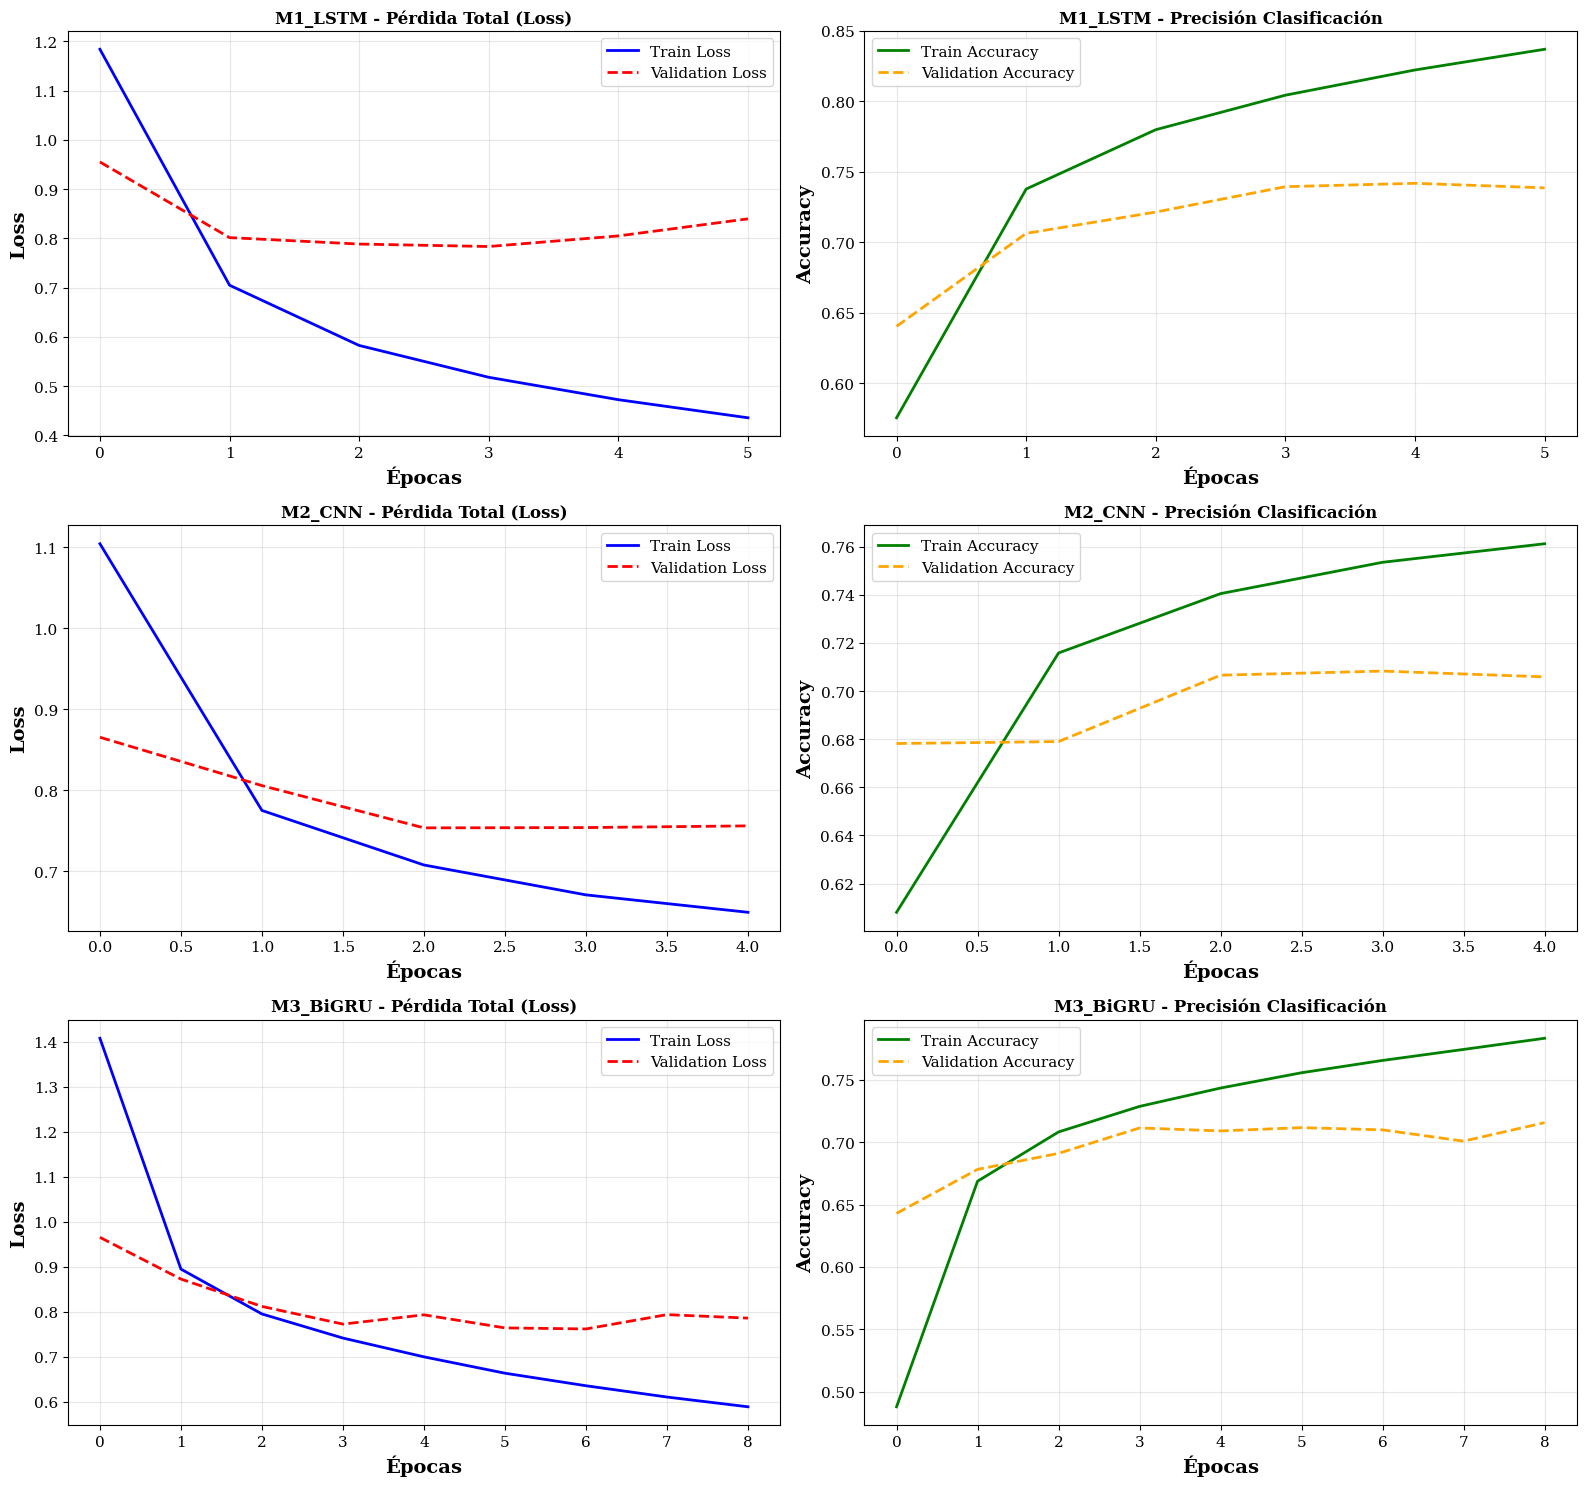


🎯 MÉTRICAS DE CLASIFICACIÓN (ENSEMBLE)
              precision    recall  f1-score   support

      ALTICA     0.8727    0.9014    0.8868      2859
   BLACK_ROT     0.6842    0.5103    0.5846     39132
    BOTRYTIS     0.4086    0.5399    0.4652     30119
    EMPOASCA     0.9454    0.9720    0.9585     23165
    ERINOSIS     0.5294    0.6387    0.5789     11556
        ESCA     0.8851    0.9756    0.9282     22053
     HEALTHY     0.8615    0.8518    0.8566     41117
     LOBESIA     0.7241    0.7457    0.7347     22824
      MILDIU     0.4484    0.3944    0.4197     20013
       OIDIO     0.9287    0.8618    0.8940      5968
    RED_MITE     0.9559    0.5257    0.6783      5568

    accuracy                         0.7052    224374
   macro avg     0.7494    0.7198    0.7260    224374
weighted avg     0.7171    0.7052    0.7055    224374



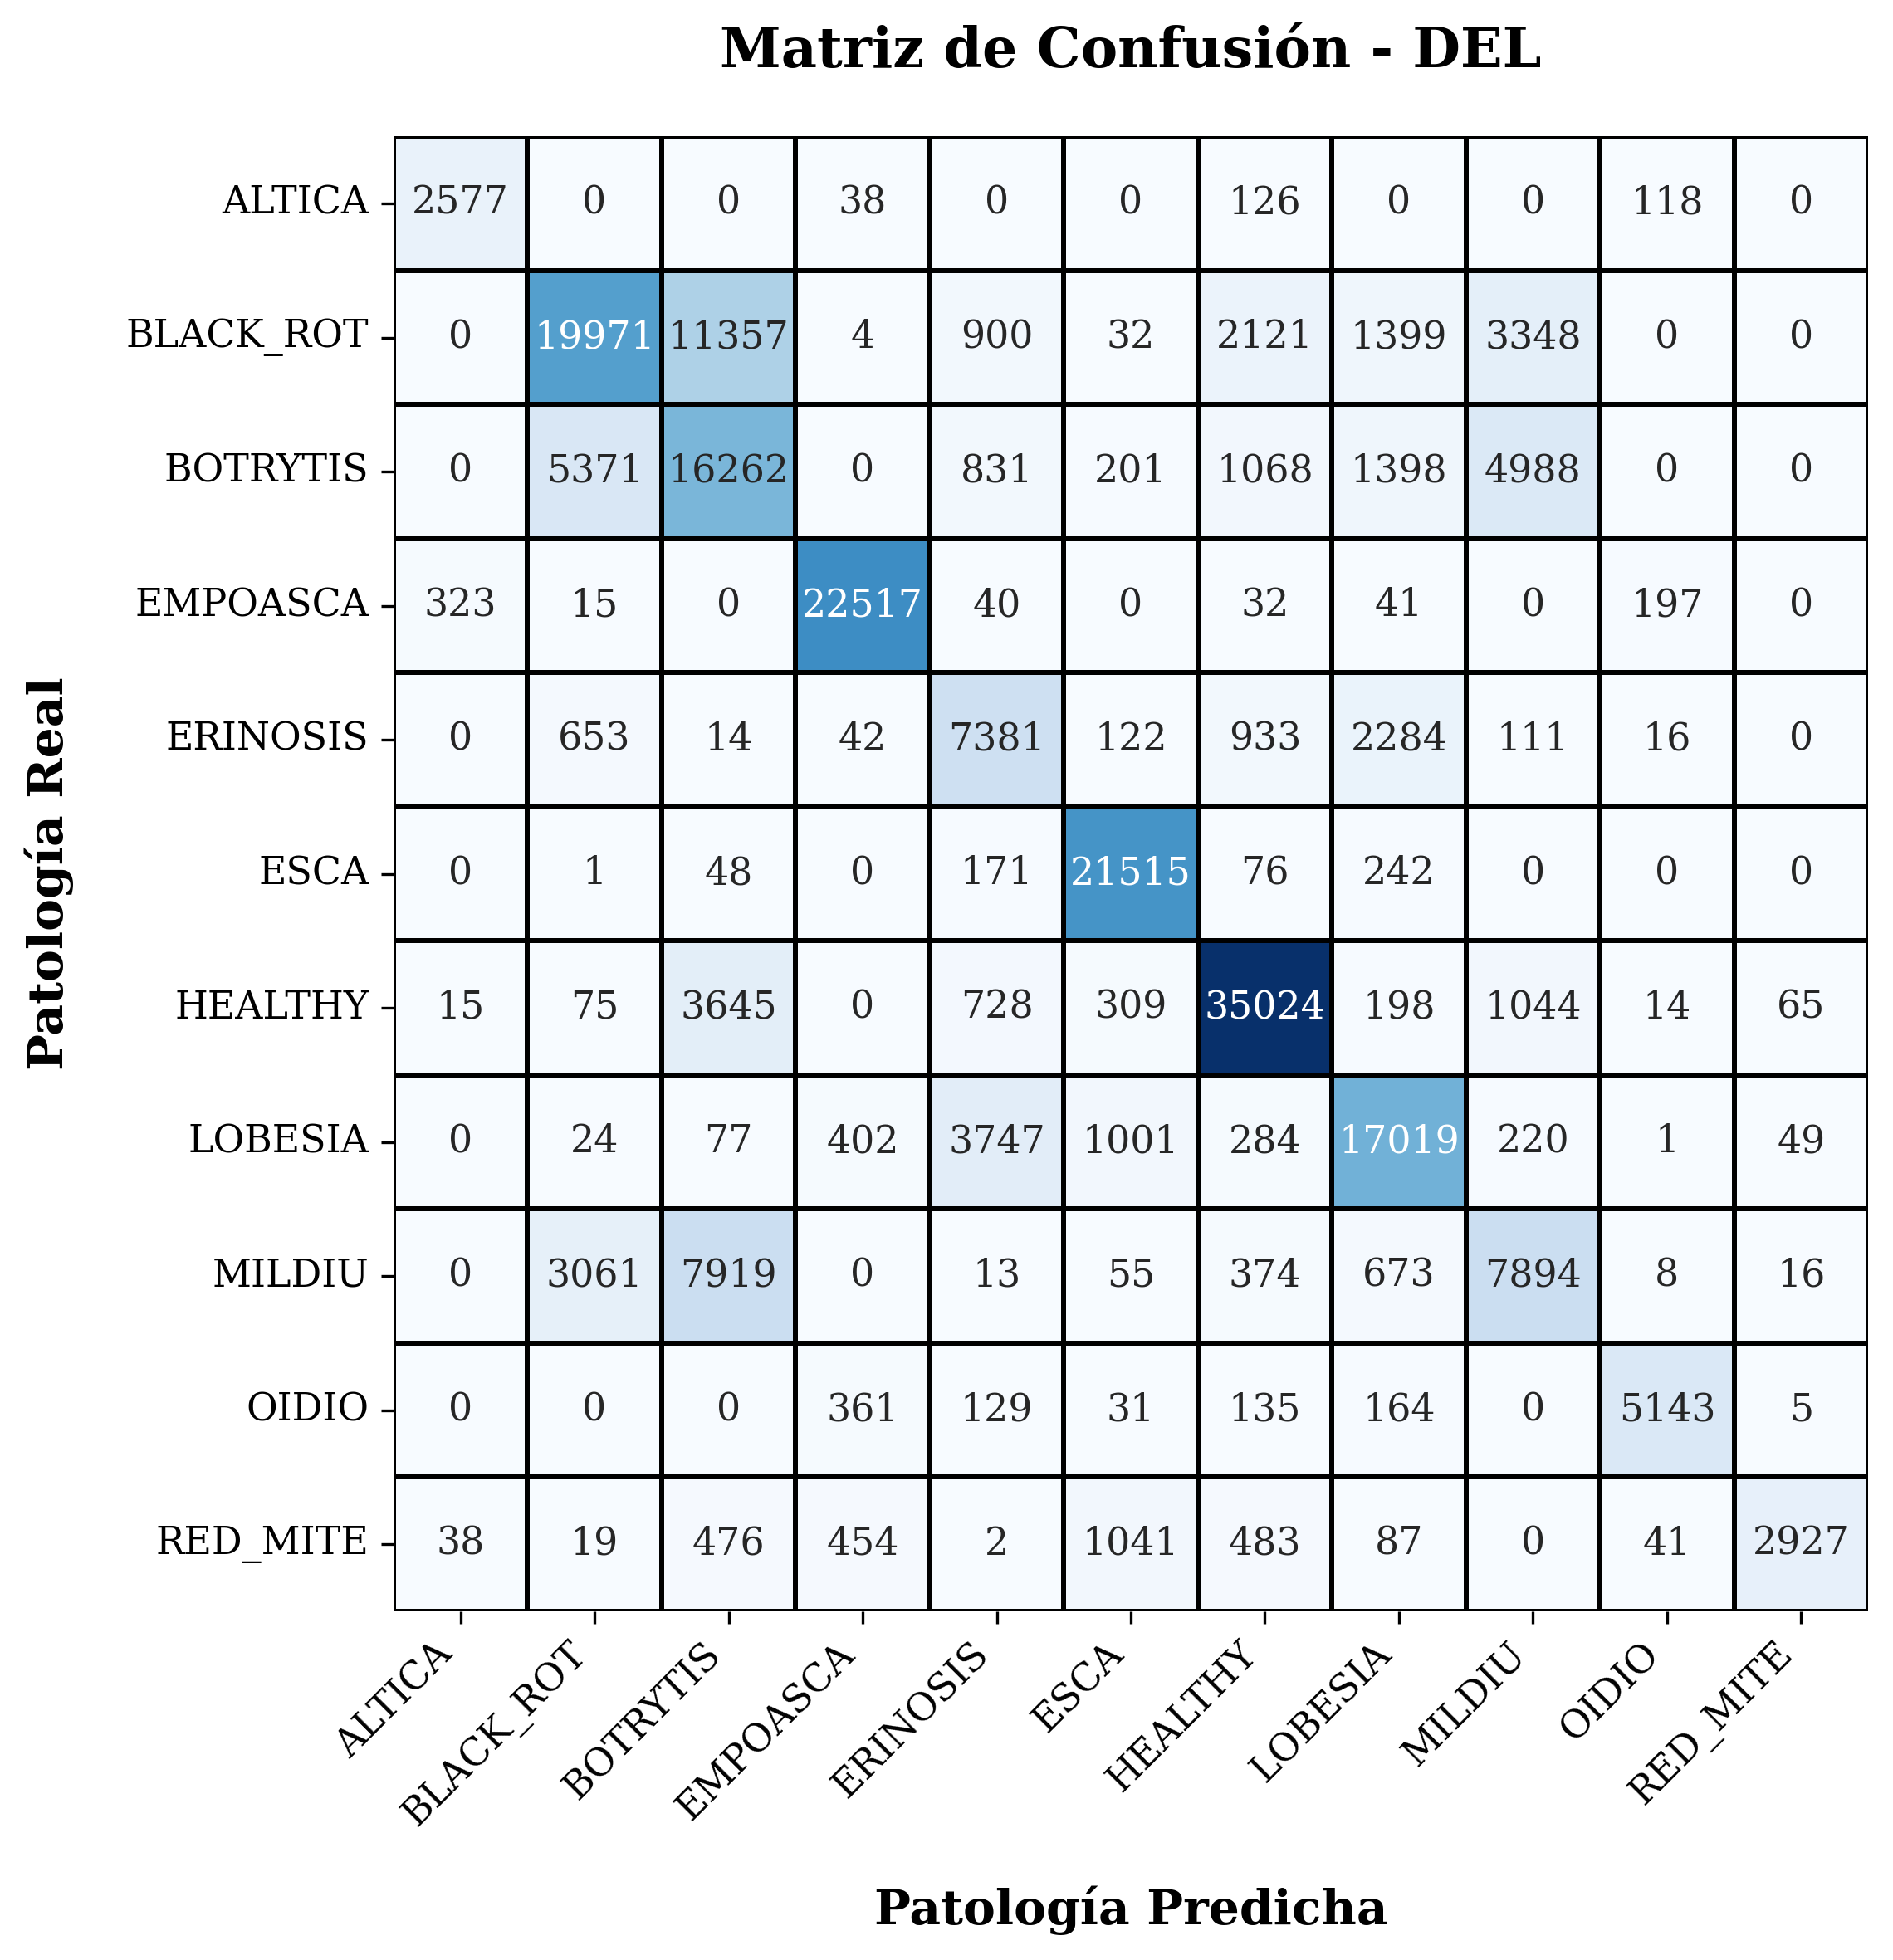


📈 MÉTRICAS DE REGRESIÓN (ENSEMBLE)
MAE  (Mean Absolute Error):      0.0610  (Error medio absoluto en la predicción del daño 0-1)
MSE  (Mean Squared Error):       0.0088  (Penaliza errores grandes)
RMSE (Root Mean Squared Error):  0.0936  (Error estándar en las mismas unidades que la salida)
R2   (Coeficiente Determinación): 0.8903  (Varianza explicada por el modelo. Max 1.0)


In [52]:
# ==============================================================================
# 10. EVALUACIÓN VISUAL Y MÉTRICAS
# ==============================================================================

# --- 1. GRÁFICAS DE PÉRDIDA (LEARNING CURVES) ---
print("📊 Generando curvas de aprendizaje para auditar el sobreajuste (Overfitting)...")

fig, axes = plt.subplots(len(historiales), 2, figsize=(16, 5 * len(historiales)))

for i, (hist, modelo) in enumerate(zip(historiales, modelos)):
    # Gráfica de Pérdida Total (Loss)
    axes[i, 0].plot(hist['loss'], label='Train Loss', color='blue', linewidth=2)
    axes[i, 0].plot(hist['val_loss'], label='Validation Loss', color='red', linestyle='--', linewidth=2)
    axes[i, 0].set_title(f'{modelo.name} - Pérdida Total (Loss)', fontsize=12, fontweight='bold')
    axes[i, 0].set_ylabel('Loss')
    axes[i, 0].set_xlabel('Épocas')
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)

    # Gráfica de Precisión de Clasificación (Accuracy)
    # Keras nombra las métricas combinando el nombre de la capa de salida
    acc_key = 'out_class_accuracy' if 'out_class_accuracy' in hist else 'accuracy'
    val_acc_key = 'val_out_class_accuracy' if 'val_out_class_accuracy' in hist else 'val_accuracy'
    
    if acc_key in hist:
        axes[i, 1].plot(hist[acc_key], label='Train Accuracy', color='green', linewidth=2)
        axes[i, 1].plot(hist[val_acc_key], label='Validation Accuracy', color='orange', linestyle='--', linewidth=2)
        axes[i, 1].set_title(f'{modelo.name} - Precisión Clasificación', fontsize=12, fontweight='bold')
        axes[i, 1].set_ylabel('Accuracy')
        axes[i, 1].set_xlabel('Épocas')
        axes[i, 1].legend()
        axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 2. MÉTRICAS DE CLASIFICACIÓN (QUÉ PATOLOGÍA ES) ---
print("\n" + "="*50)
print("🎯 MÉTRICAS DE CLASIFICACIÓN (ENSEMBLE)")
print("="*50)

y_test_real_nombres = le.inverse_transform(y_test_class)

# Classification Report (Incluye Precision, Recall, F1-Score y Accuracy Macro)
reporte = classification_report(y_test_real_nombres, pred_clase, digits=4)
print(reporte)

# MATRIZ DE CONFUSIÓN:
# Configuración global de la fuente (Estilo Paper / LaTeX)
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold'
})

# Cálculo de la matriz
cm = confusion_matrix(y_test_real_nombres, pred_clase, labels=le.classes_)

# Creación de la figura en Alta Resolución (dpi=300 vital para papers)
plt.figure(figsize=(10, 8), dpi=300)

# Heatmap estilizado (Corregido yticklabels)
ax = sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=le.classes_, 
    yticklabels=le.classes_,                       
    cbar=False,                                     
    cbar_kws={'shrink': 0.8, 'pad': 0.02},         
    linewidths=1, 
    linecolor='black',                             
    square=True                                    
)

# Títulos y Etiquetas con espaciado (pad)
plt.title('Matriz de Confusión - DEL', pad=20)
plt.ylabel('Patología Real', labelpad=15)
plt.xlabel('Patología Predicha', labelpad=15)

# Rotación de los ticks para legibilidad
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- 3. MÉTRICAS DE REGRESIÓN (CUÁNTO DAÑO HAY) ---
print("\n" + "="*50)
print("📈 MÉTRICAS DE REGRESIÓN (ENSEMBLE)")
print("="*50)

mae = mean_absolute_error(y_test_reg, pred_grado)
mse = mean_squared_error(y_test_reg, pred_grado)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, pred_grado)

print(f"MAE  (Mean Absolute Error):      {mae:.4f}  (Error medio absoluto en la predicción del daño 0-1)")
print(f"MSE  (Mean Squared Error):       {mse:.4f}  (Penaliza errores grandes)")
print(f"RMSE (Root Mean Squared Error):  {rmse:.4f}  (Error estándar en las mismas unidades que la salida)")
print(f"R2   (Coeficiente Determinación): {r2:.4f}  (Varianza explicada por el modelo. Max 1.0)")
print("="*50)

### **MÉTRICAS POR MODELO**

EVALUACIÓN DE RENDIMIENTO INDIVIDUAL POR MODELO

--------------------------------------------------
🧠 Evaluando modelo: M1_LSTM
--------------------------------------------------
🎯 Métricas de Clasificación:
  - Accuracy:  0.6748 (Precisión global)
  - Precision: 0.7318 (Media Macro)
  - Recall:    0.6994 (Media Macro)
  - F1-Score:  0.7064 (Media Macro)

📈 Métricas de Regresión:
  - MAE:  0.0701
  - RMSE: 0.1066
  - R2:   0.8575


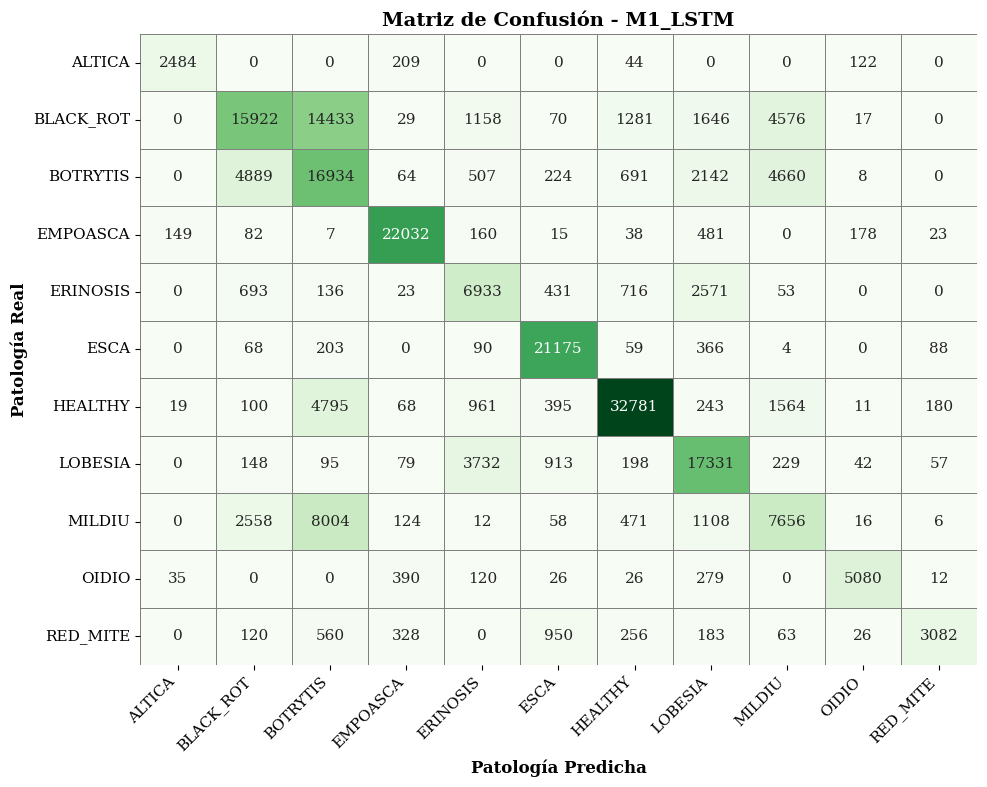


--------------------------------------------------
🧠 Evaluando modelo: M2_CNN
--------------------------------------------------
🎯 Métricas de Clasificación:
  - Accuracy:  0.6874 (Precisión global)
  - Precision: 0.7199 (Media Macro)
  - Recall:    0.6966 (Media Macro)
  - F1-Score:  0.7034 (Media Macro)

📈 Métricas de Regresión:
  - MAE:  0.0779
  - RMSE: 0.1149
  - R2:   0.8346


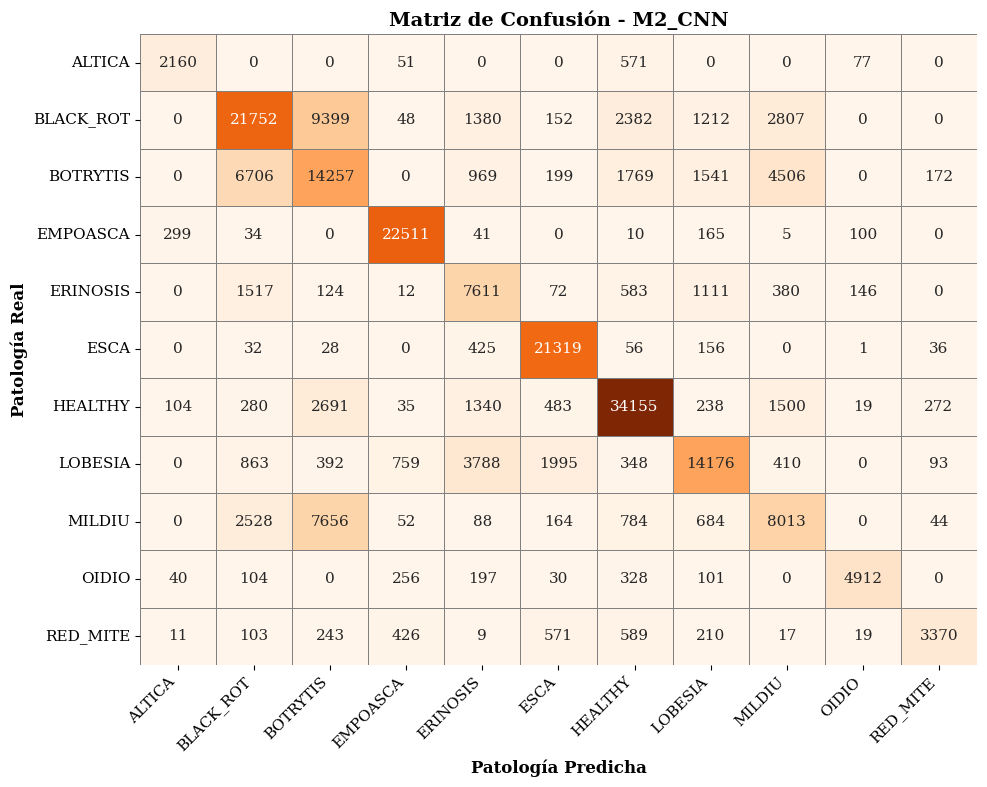


--------------------------------------------------
🧠 Evaluando modelo: M3_BiGRU
--------------------------------------------------
🎯 Métricas de Clasificación:
  - Accuracy:  0.6444 (Precisión global)
  - Precision: 0.6504 (Media Macro)
  - Recall:    0.6384 (Media Macro)
  - F1-Score:  0.6383 (Media Macro)

📈 Métricas de Regresión:
  - MAE:  0.0786
  - RMSE: 0.1170
  - R2:   0.8283


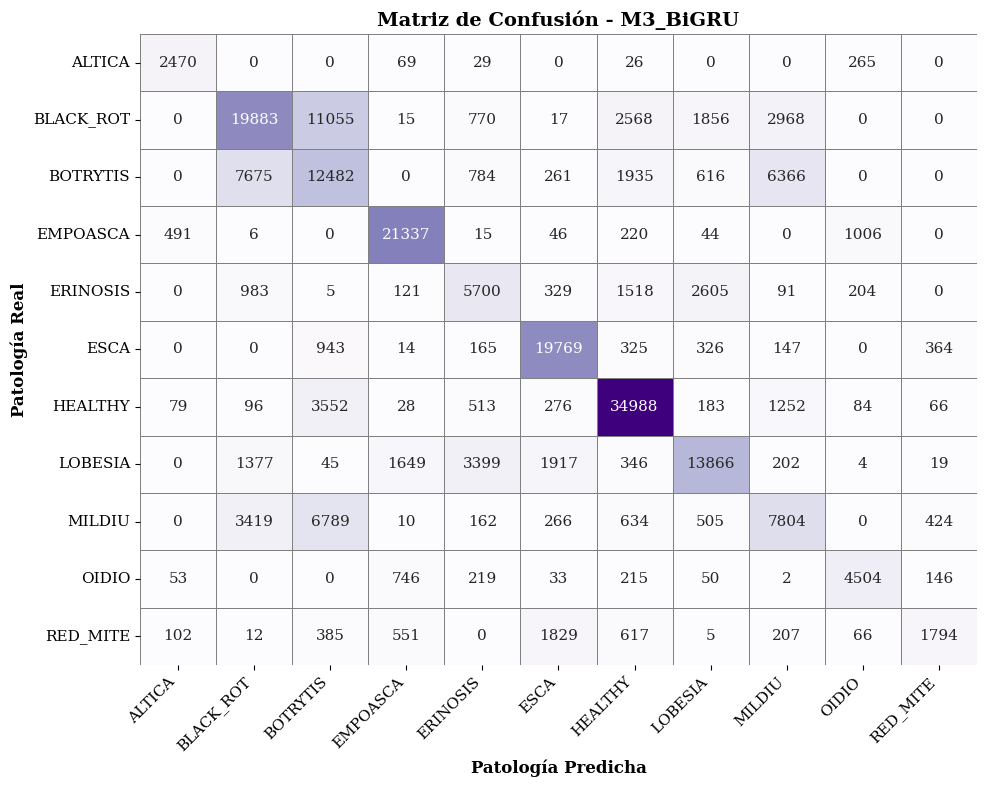


📊 RESUMEN COMPARATIVO DE LOS MODELOS


,Accuracy,F1-Score,MAE,R2
M1_LSTM,0.6748,0.7064,0.0701,0.8575
M2_CNN,0.6874,0.7034,0.0779,0.8346
M3_BiGRU,0.6444,0.6383,0.0786,0.8283


In [53]:
# ==============================================================================
# 11. EVALUACIÓN INDIVIDUAL POR MODELO (LSTM, CNN, BiGRU)
# ==============================================================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("="*60)
print("EVALUACIÓN DE RENDIMIENTO INDIVIDUAL POR MODELO")
print("="*60)

# Convertimos las etiquetas reales a sus nombres en texto para la matriz de confusión
y_test_real_nombres = le.inverse_transform(y_test_class)

# Diccionario para ir guardando un resumen y poder comparar al final
resumen_metricas = {}

for modelo in modelos:
    print(f"\n" + "-" * 50)
    print(f"🧠 Evaluando modelo: {modelo.name}")
    print("-" * 50)
    
    # 1. PREDICCIÓN
    # El modelo devuelve dos arrays: probabilidades de clasificación y valores de regresión
    p_class, p_reg = modelo.predict(X_test, batch_size=512, verbose=0)
    
    # Procesamos las salidas
    pred_clases_idx = np.argmax(p_class, axis=1)
    pred_grado = p_reg.flatten()
    pred_clases_nombres = le.inverse_transform(pred_clases_idx)
    
    # 2. MÉTRICAS DE CLASIFICACIÓN (Macro average)
    acc = accuracy_score(y_test_class, pred_clases_idx)
    prec = precision_score(y_test_class, pred_clases_idx, average='macro', zero_division=0)
    rec = recall_score(y_test_class, pred_clases_idx, average='macro', zero_division=0)
    f1 = f1_score(y_test_class, pred_clases_idx, average='macro', zero_division=0)
    
    print(f"🎯 Métricas de Clasificación:")
    print(f"  - Accuracy:  {acc:.4f} (Precisión global)")
    print(f"  - Precision: {prec:.4f} (Media Macro)")
    print(f"  - Recall:    {rec:.4f} (Media Macro)")
    print(f"  - F1-Score:  {f1:.4f} (Media Macro)")
    
    # 3. MÉTRICAS DE REGRESIÓN
    mae = mean_absolute_error(y_test_reg, pred_grado)
    rmse = np.sqrt(mean_squared_error(y_test_reg, pred_grado))
    r2 = r2_score(y_test_reg, pred_grado)
    
    print(f"\n📈 Métricas de Regresión:")
    print(f"  - MAE:  {mae:.4f}")
    print(f"  - RMSE: {rmse:.4f}")
    print(f"  - R2:   {r2:.4f}")
    
    # Guardamos en el diccionario para imprimir una tabla resumen luego
    resumen_metricas[modelo.name] = {
        'Accuracy': acc, 'F1-Score': f1, 'MAE': mae, 'R2': r2
    }
    
    # 4. MATRIZ DE CONFUSIÓN
    cm = confusion_matrix(y_test_real_nombres, pred_clases_nombres, labels=le.classes_)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges' if 'CNN' in modelo.name else ('Greens' if 'LSTM' in modelo.name else 'Purples'), 
                xticklabels=le.classes_, yticklabels=le.classes_,
                cbar=False, linewidths=0.5, linecolor='gray')
    plt.title(f'Matriz de Confusión - {modelo.name}', fontsize=14, fontweight='bold')
    plt.ylabel('Patología Real', fontsize=12)
    plt.xlabel('Patología Predicha', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# ==============================================================================
# TABLA RESUMEN FINAL
# ==============================================================================
print("\n" + "="*60)
print("📊 RESUMEN COMPARATIVO DE LOS MODELOS")
print("="*60)
df_resumen = pd.DataFrame(resumen_metricas).T
display(df_resumen.round(4))

### **MÉTRICAS POR FAMILIA DE TRATAMIENTOS**


🎯 MÉTRICAS RECALCULADAS POR FAMILIA DE TRATAMIENTO
                         precision    recall  f1-score   support

      Sano (Sin Acción)     0.8615    0.8518    0.8566     41117
  Tratamiento Acaricida     0.6063    0.6021    0.6042     17124
Tratamiento Estructural     0.8851    0.9756    0.9282     22053
    Tratamiento Fúngico     0.9261    0.8959    0.9108     95232
Tratamiento Insecticida     0.8536    0.8786    0.8659     48848

               accuracy                         0.8695    224374
              macro avg     0.8265    0.8408    0.8331    224374
           weighted avg     0.8700    0.8695    0.8694    224374



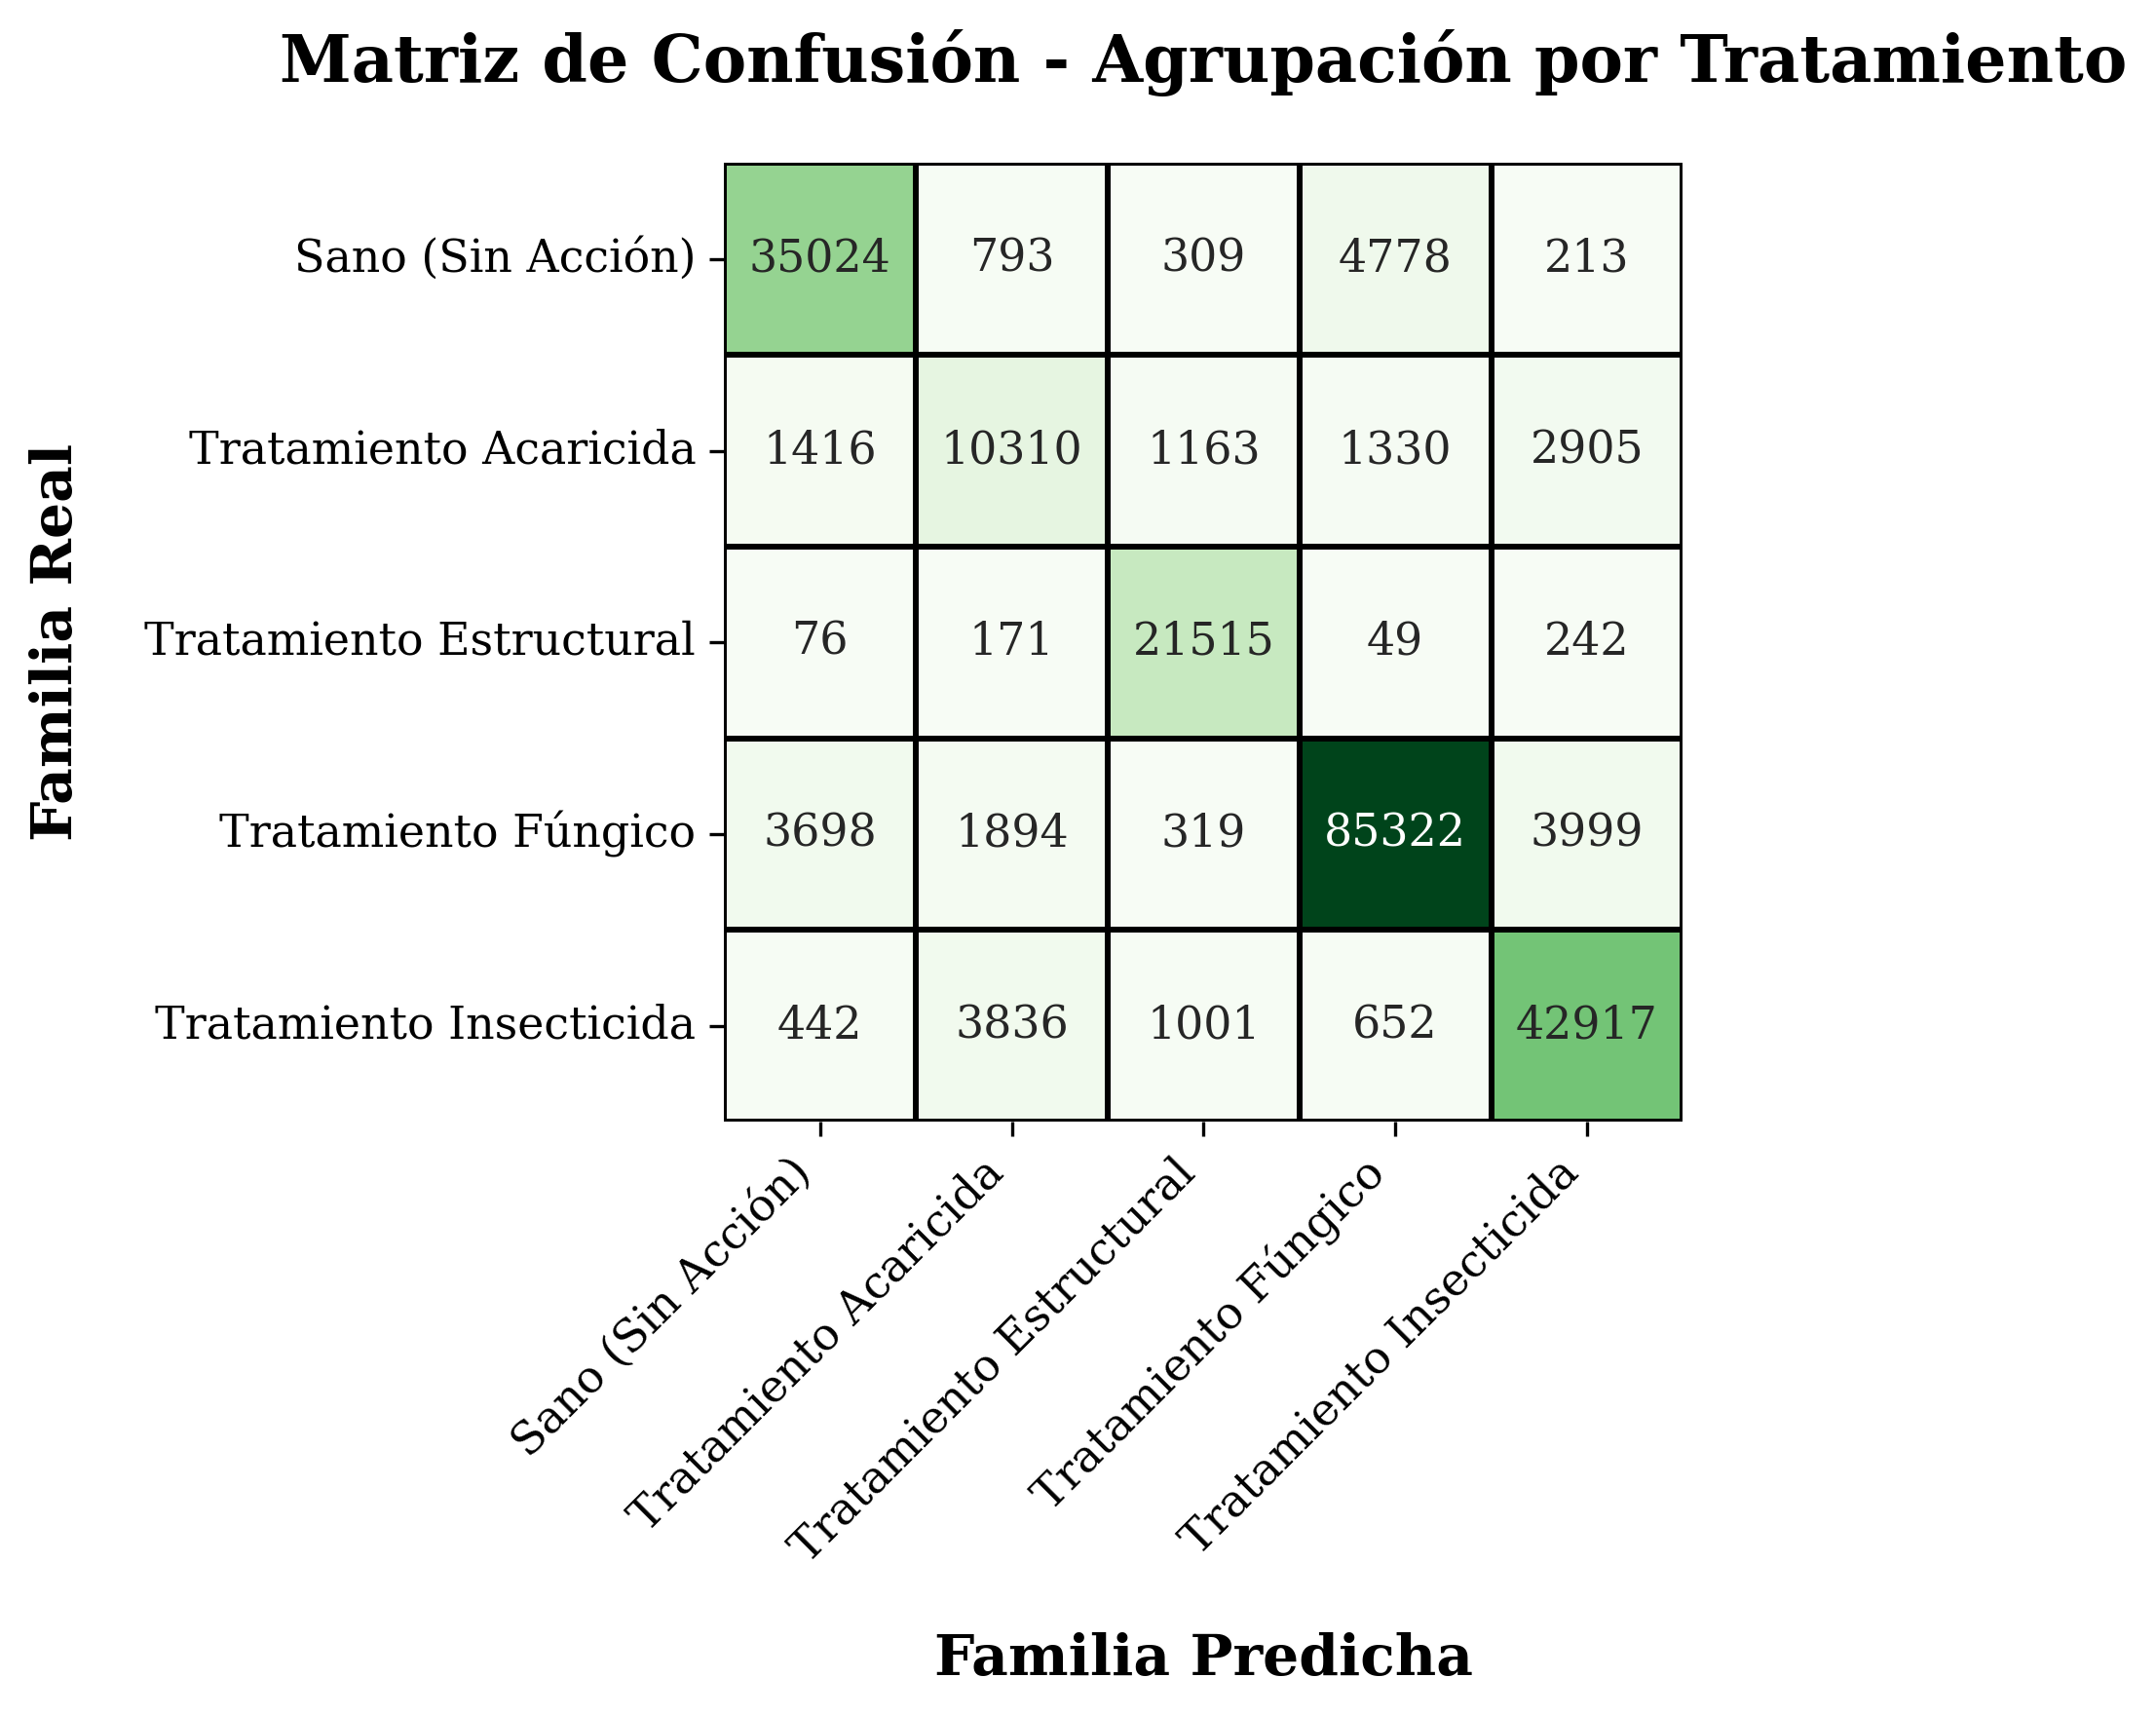

In [54]:
# ==============================================================================
# 10.B MÉTRICAS AGRUPADAS POR FAMILIA DE TRATAMIENTO (JUSTIFICACIÓN DE NEGOCIO)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# 1. Definimos la transformación de clases a Familias de Tratamiento
mapeo_tratamientos = {
    "HEALTHY": "Sano (Sin Acción)",
    
    # Tratamientos Fúngicos (Fungicidas sistémicos / penetrantes)
    "BLACK_ROT": "Tratamiento Fúngico",
    "BOTRYTIS": "Tratamiento Fúngico",
    "MILDIU": "Tratamiento Fúngico",
    "OIDIO": "Tratamiento Fúngico",
    
    # Tratamientos Insecticidas (Clorpirifos, Bacillus, etc.)
    "ALTICA": "Tratamiento Insecticida",
    "EMPOASCA": "Tratamiento Insecticida",
    "LOBESIA": "Tratamiento Insecticida",
    
    # Tratamientos Acaricidas (Dicofol, Aceites, Azufre específico)
    "ERINOSIS": "Tratamiento Acaricida",
    "RED_MITE": "Tratamiento Acaricida",
    
    # Tratamientos Estructurales (Poda, Mastic)
    "ESCA": "Tratamiento Estructural"
}

# 2. Aplicamos el mapeo a las predicciones y a los valores reales
y_test_familias_real = [mapeo_tratamientos[clase] for clase in y_test_real_nombres]
y_test_familias_pred = [mapeo_tratamientos[clase] for clase in pred_clase]

# 3. Obtenemos las etiquetas únicas ordenadas
clases_agrupadas = sorted(list(set(mapeo_tratamientos.values())))

# 4. Reporte de Clasificación Agrupado
print("\n" + "="*60)
print("🎯 MÉTRICAS RECALCULADAS POR FAMILIA DE TRATAMIENTO")
print("="*60)
reporte_agrupado = classification_report(y_test_familias_real, y_test_familias_pred, digits=4)
print(reporte_agrupado)

# 5. Nueva Matriz de Confusión Agrupada
cm_agrupada = confusion_matrix(y_test_familias_real, y_test_familias_pred, labels=clases_agrupadas)

plt.figure(figsize=(8, 6), dpi=300)
sns.heatmap(
    cm_agrupada, 
    annot=True, 
    fmt='d', 
    cmap='Greens', 
    xticklabels=clases_agrupadas, 
    yticklabels=clases_agrupadas,                        
    cbar=False,                                     
    linewidths=1, 
    linecolor='black',                              
    square=True                                     
)

plt.title('Matriz de Confusión - Agrupación por Tratamiento', pad=20)
plt.ylabel('Familia Real', labelpad=15)
plt.xlabel('Familia Predicha', labelpad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### **INFERENCIA PARA PRODUCCIÓN**

In [55]:
import time

def inferencia_produccion(df_raw, modelos_ensemble, scaler_path, le_path, base_conocimiento, ruta_salida="inferencia_vid.csv"):
    """
    Ejecuta la inferencia en producción para un contexto de WINDOW_SIZE horas.
    """
    df = df_raw.copy()
    
    # 1. COMPROBACIÓN Y AJUSTE DE LONGITUD
    n_filas = len(df)
    if n_filas > WINDOW_SIZE:
        # Pasting: Nos quedamos con las últimas WINDOW_SIZE horas
        df = df.tail(WINDOW_SIZE).copy()
        print(f"Aviso: Se ha recortado la serie de {n_filas} a {WINDOW_SIZE} horas (últimos datos).")
    elif n_filas < WINDOW_SIZE:
        # Padding: Clonamos la fila más antigua (índice 0) hacia atrás para no meter ceros irreales
        filas_faltantes = WINDOW_SIZE - n_filas
        df_pad = pd.concat([df.iloc[[0]]] * filas_faltantes, ignore_index=True)
        df = pd.concat([df_pad, df], ignore_index=True)
        print(f"Aviso: Se ha hecho padding de {filas_faltantes} horas repitiendo el estado inicial.")

    df.reset_index(drop=True, inplace=True)

    # 2. INGENIERÍA DE CARACTERÍSTICAS (Mismo pipeline que en Train)
    if 'Fecha' in df.columns:
        df['Fecha'] = pd.to_datetime(df['Fecha'])
        df['Hora'] = df['Fecha'].dt.hour
        df['Hora_Sin'] = np.sin(2 * np.pi * df['Hora'] / 24).astype('float32')
        df['Hora_Cos'] = np.cos(2 * np.pi * df['Hora'] / 24).astype('float32')
    else:
        raise ValueError("Error: Falta la columna 'Fecha' en el DataFrame de entrada.")

    # 3. COMPROBACIÓN DE COLUMNAS REQUERIDAS
    cols_features = [
        'Temp_Amb_C', 
        'Hum_Rel_Pct', 'Lluvia_mm', 'Viento_kmh', 
        'Horas_Humedad_Foliar', 'GDD_Acumulado', 
        'Hum_Suelo_Pct', 'pH_Suelo',
        'CO2_ppm', 'VOC_ppb',
        'Hora_Sin', 'Hora_Cos'
    ]
    
    columnas_faltantes = [col for col in cols_features if col not in df.columns]
    if columnas_faltantes:
        raise ValueError(f"Error: Faltan las siguientes columnas requeridas: {columnas_faltantes}")

    # Seleccionar solo las columnas necesarias en el orden exacto
    X_input = df[cols_features].copy()

    # 4. CARGA DE ARTEFACTOS Y ESCALADO
    scaler = joblib.load(scaler_path)
    le = joblib.load(le_path)
    
    X_scaled = scaler.transform(X_input)
    
    # 5. RESHAPE PARA EL MODELO
    X_tensor = X_scaled.reshape(1, WINDOW_SIZE, len(cols_features))

    # 6. PREDICCIÓN CON EL ENSEMBLE
    preds_clases_prob = []
    preds_regresion = []
    
    # Iniciamos el cronómetro justo antes de que los modelos empiecen a predecir
    inicio_inferencia = time.perf_counter()
    
    for mod in modelos_ensemble:
        p_class, p_reg = mod.predict(X_tensor, verbose=0)
        preds_clases_prob.append(p_class)
        preds_regresion.append(p_reg)
        
    # Soft Voting y Averaging
    media_probs = np.mean(preds_clases_prob, axis=0)
    clase_ganadora_idx = np.argmax(media_probs, axis=1)[0]
    confianza = np.max(media_probs, axis=1)[0]
    grado_infeccion = np.mean(preds_regresion, axis=0).flatten()[0]
    
    patologia_predicha = le.inverse_transform([clase_ganadora_idx])[0]
    
    # Paramos el cronómetro justo después de tener la decisión final del Ensemble
    fin_inferencia = time.perf_counter()
    tiempo_inferencia = fin_inferencia - inicio_inferencia

    # 7. INTEGRACIÓN CON BASE DE CONOCIMIENTO
    tratamiento_dict = base_conocimiento.get(patologia_predicha, {"Aviso": "Patología no encontrada en base de conocimiento."})
    
    # Formatear el diccionario a un string legible para el CSV
    tratamiento_str = " | ".join([f"{k}: {v}" for k, v in tratamiento_dict.items()])

    # 8. EXPORTACIÓN A CSV
    resultado_df = pd.DataFrame([{
        "Fecha_Evaluacion": df['Fecha'].iloc[-1], # La hora actual (última de la ventana)
        "Diagnostico_IA": patologia_predicha,
        "Confianza_Clasificacion": f"{confianza * 100:.2f}%",
        "Grado_Severidad (0-1)": round(float(grado_infeccion), 4),
        "Tratamiento_Recomendado": tratamiento_str,
        "Tiempo_Inferencia_Seg": round(tiempo_inferencia, 4) # Guardamos el tiempo de inferencia en el CSV para llevar registro
    }])

    resultado_df.to_csv(ruta_salida, index=False, encoding='utf-8-sig')
    print(f"\n✅ Predicción guardada con éxito en: {ruta_salida}")
    print(f"Tiempo de inferencia (sólo predicción del modelo): {tiempo_inferencia:.4f} segundos") 
    
    return resultado_df

In [56]:
# ==============================================================================
# EJECUCIÓN EN PRODUCCIÓN
# ==============================================================================
# 1. Filtramos una serie específica (simulando leer un sensor de una parcela)
# Elegimos la parcela ID_Serie = 3 (por ejemplo)
df_sensor_raw = df[df['ID_Serie'] == 3].copy()

# 2. Le quitamos las columnas trampa que en la vida real no tendrías
columnas_prohibidas = ['Etiqueta_Clase', 'Grado_Infeccion', 'Clase_Entrenamiento', 'ID_Serie', 'Etiqueta_Num', 'Parcela_ID']
df_produccion = df_sensor_raw.drop(columns=columnas_prohibidas, errors='ignore')

display(df_produccion.head(2))
print("\n")

# Definimos las rutas de los modelos:
ruta_scaler = RUTA_MODELS_DIR / NOMBRE_SCALER
ruta_le = RUTA_MODELS_DIR / NOMBRE_LABEL_ENCODER
ruta_output_csv = OUTPUT_DIR / NOMBRE_PREDICT_CSV

# Empezamos a medir el tiempo de toda la tubería o pipeline completo
inicio_pipeline = time.perf_counter()

# 3. Ejecutamos la Inferencia
resultado_produccion = inferencia_produccion(
    df_raw = df_produccion,
    modelos_ensemble = modelos,
    scaler_path = ruta_scaler,
    le_path = ruta_le,
    base_conocimiento = BASE_CONOCIMIENTO_TRATAMIENTOS,
    ruta_salida = ruta_output_csv
)

# Terminamos de medir el tiempo de todo el proceso
fin_pipeline = time.perf_counter()
tiempo_total_evaluacion = fin_pipeline - inicio_pipeline

print(f"\n⏱️ Tiempo TOTAL de evaluación (pipeline completo, preprocesamiento + inferencia + escritura CSV): {tiempo_total_evaluacion:.4f} segundos")

# 4. Mostramos la tabla por pantalla
print("\nSALIDA DEL MODELO (RESULTADO DE LA PREDICCIÓN):")
display(resultado_produccion)

print("\nDATOS REALES:")
display(df_sensor_raw.tail(1))

,CO2_ppm,Fecha,GDD_Acumulado,Hora,Hora_Cos,Hora_Sin,Horas_Humedad_Foliar,Hum_Rel_Pct,Hum_Suelo_Pct,Lluvia_mm,Temp_Amb_C,VOC_ppb,Viento_kmh,pH_Suelo
3871,398.415680,2022-06-07 10:00:00,10.65,10,-0.866025,0.500000,0.0,70.0,24.782581,0.0,16.299999,119.681961,1.5,6.634698
3872,394.939911,2022-06-07 11:00:00,10.65,11,-0.965926,0.258819,0.0,58.0,24.777594,0.0,18.400000,96.952354,3.3,6.604490




Aviso: Se ha recortado la serie de 319 a 168 horas (últimos datos).

✅ Predicción guardada con éxito en: ..\..\data\predictions\inferencia_vid.csv
Tiempo de inferencia (sólo predicción del modelo): 0.1824 segundos

⏱️ Tiempo TOTAL de evaluación (pipeline completo, preprocesamiento + inferencia + escritura CSV): 0.1902 segundos

SALIDA DEL MODELO (RESULTADO DE LA PREDICCIÓN):


c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,Fecha_Evaluacion,Diagnostico_IA,Confianza_Clasificacion,Grado_Severidad (0-1),Tratamiento_Recomendado,Tiempo_Inferencia_Seg
0,2022-06-20 16:00:00,ALTICA,60.91%,0.7673,Químico: Generalmente controlado por tratamien...,0.1824



DATOS REALES:


,CO2_ppm,Clase_Entrenamiento,Etiqueta_Clase,Fecha,GDD_Acumulado,Grado_Infeccion,Hora,Hora_Cos,Hora_Sin,Horas_Humedad_Foliar,Hum_Rel_Pct,Hum_Suelo_Pct,ID_Serie,Lluvia_mm,Parcela_ID,Temp_Amb_C,VOC_ppb,Viento_kmh,pH_Suelo,Etiqueta_Num
4189,409.445953,ALTICA,ALTICA,2022-06-20 16:00:00,183.324997,1.0,16,-0.5,-0.866025,0.0,45.0,25.263824,3,0.1,bierzo,19.4,41.973225,13.4,6.564528,0
